In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/amazon_cleaned.csv')
sns.set_theme(style="whitegrid")

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Rows: 121180, Columns: 21


C:\Users\jvaru\AppData\Local\Temp\ipykernel_22632\3732331487.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly, x='Month', y='Amount', palette='Blues_d')


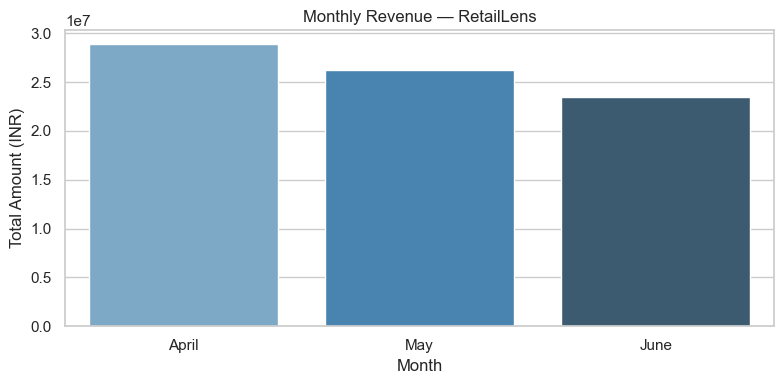

In [2]:
monthly = df.groupby('Month_Num')['Amount'].sum().reset_index()
month_names = {4: 'April', 5: 'May', 6: 'June'}
monthly['Month'] = monthly['Month_Num'].map(month_names)

plt.figure(figsize=(8, 4))
sns.barplot(data=monthly, x='Month', y='Amount', palette='Blues_d')
plt.title('Monthly Revenue — RetailLens')
plt.ylabel('Total Amount (INR)')
plt.tight_layout()
plt.savefig('../data/chart_monthly_revenue.png')
plt.show()

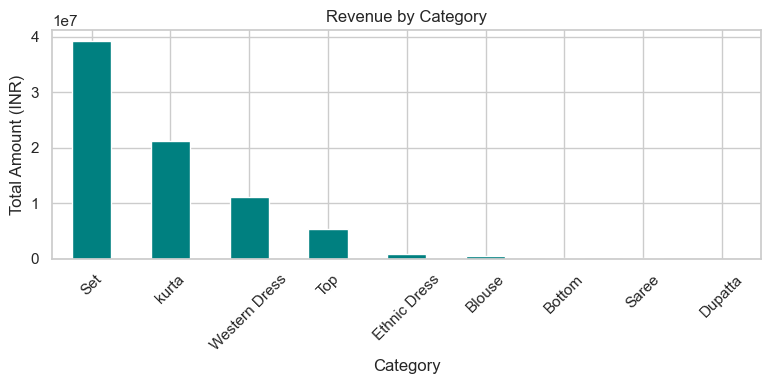

In [3]:
cat_sales = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
cat_sales.plot(kind='bar', color='teal')
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Amount (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/chart_category.png')
plt.show()

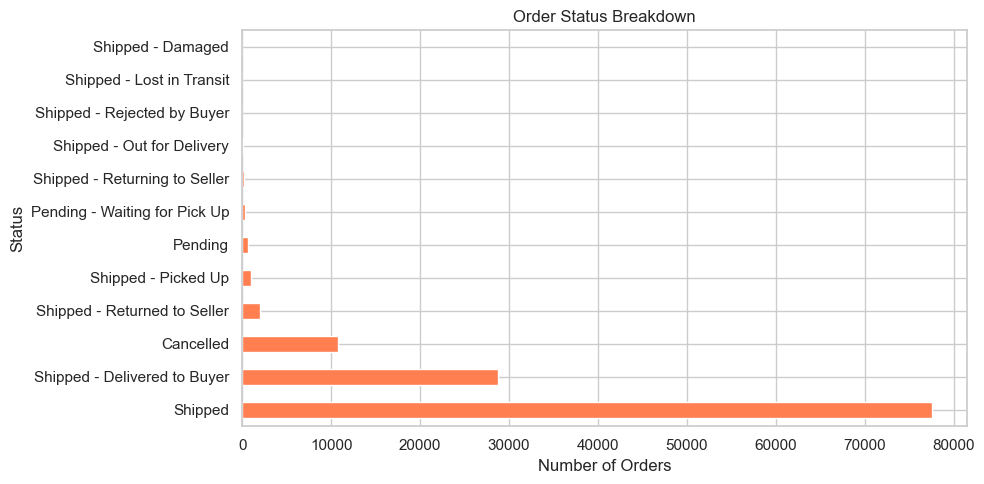

In [4]:
status_counts = df['Status'].value_counts()

plt.figure(figsize=(10, 5))
status_counts.plot(kind='barh', color='coral')
plt.title('Order Status Breakdown')
plt.xlabel('Number of Orders')
plt.ylabel('Status')
plt.tight_layout()
plt.savefig('../data/chart_status.png')
plt.show()

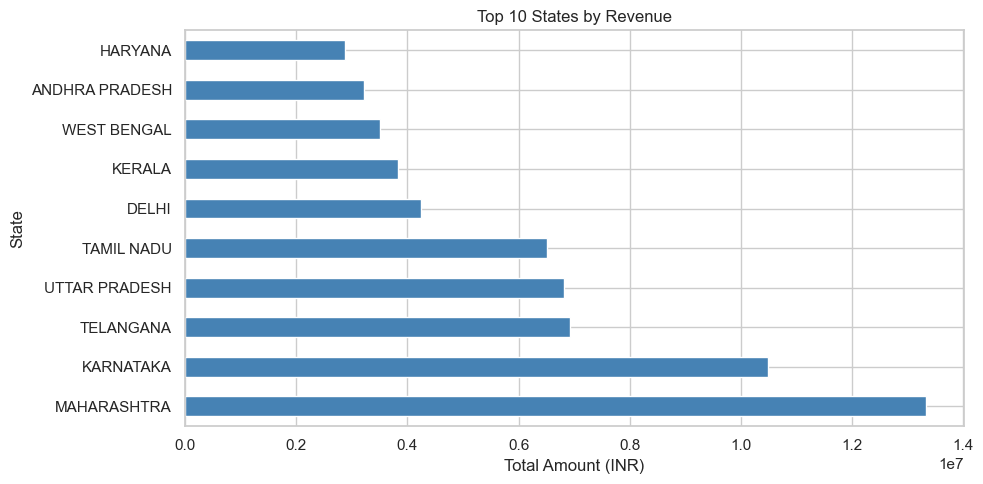

In [5]:
state_rev = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
state_rev.plot(kind='barh', color='steelblue')
plt.title('Top 10 States by Revenue')
plt.xlabel('Total Amount (INR)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('../data/chart_states.png')
plt.show()

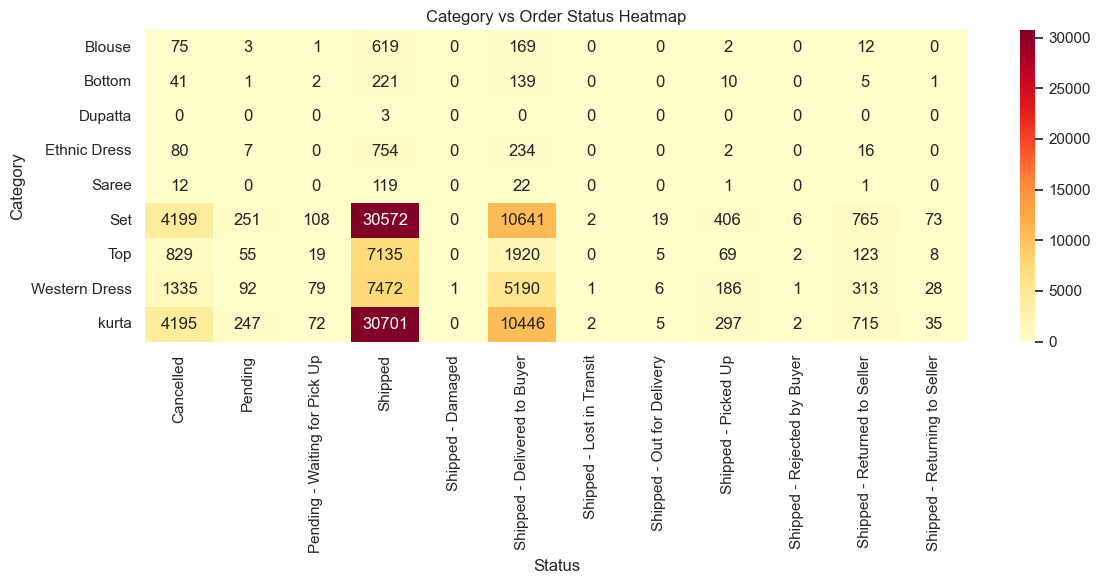

In [6]:
pivot = df.pivot_table(index='Category', columns='Status', values='Order ID', aggfunc='count', fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Category vs Order Status Heatmap')
plt.tight_layout()
plt.savefig('../data/chart_heatmap.png')
plt.show()

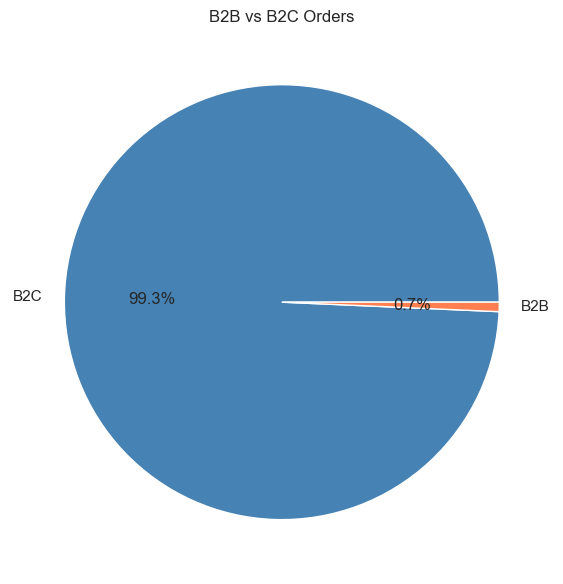

In [7]:
b2b_counts = df['B2B'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(b2b_counts, labels=['B2C', 'B2B'], autopct='%1.1f%%', colors=['steelblue', 'coral'])
plt.title('B2B vs B2C Orders')
plt.tight_layout()
plt.savefig('../data/chart_b2b_b2c.png')
plt.show()

In [8]:
print("=== RetailLens — EDA Summary ===\n")
print(f"Total Orders: {len(df):,}")
print(f"Total Revenue: ₹{df['Amount'].sum():,.2f}")
print(f"Average Order Value: ₹{df['Amount'].mean():,.2f}")
print(f"Top Category: {df.groupby('Category')['Amount'].sum().idxmax()}")
print(f"Top State: {df.groupby('ship-state')['Amount'].sum().idxmax()}")
print(f"Cancellation Rate: {(df['Status'] == 'Cancelled').sum() / len(df) * 100:.2f}%")

=== RetailLens — EDA Summary ===

Total Orders: 121,180
Total Revenue: ₹78,592,678.30
Average Order Value: ₹648.56
Top Category: Set
Top State: MAHARASHTRA
Cancellation Rate: 8.88%
